# ¡Llena ese carrito!

# Introducción

Instacart es una plataforma de entregas de comestibles donde la clientela puede registrar un pedido y hacer que se lo entreguen, similar a Uber Eats y Door Dash.
El conjunto de datos que te hemos proporcionado tiene modificaciones del original. Redujimos el tamaño del conjunto para que tus cálculos se hicieran más rápido e introdujimos valores ausentes y duplicados. Tuvimos cuidado de conservar las distribuciones de los datos originales cuando hicimos los cambios.

Debes completar tres pasos. Para cada uno de ellos, escribe una breve introducción que refleje con claridad cómo pretendes resolver cada paso, y escribe párrafos explicatorios que justifiquen tus decisiones al tiempo que avanzas en tu solución.  También escribe una conclusión que resuma tus hallazgos y elecciones.


## Diccionario de datos

Hay cinco tablas en el conjunto de datos, y tendrás que usarlas todas para hacer el preprocesamiento de datos y el análisis exploratorio de datos. A continuación se muestra un diccionario de datos que enumera las columnas de cada tabla y describe los datos que contienen.

- `instacart_orders.csv`: cada fila corresponde a un pedido en la aplicación Instacart.
    - `'order_id'`: número de ID que identifica de manera única cada pedido.
    - `'user_id'`: número de ID que identifica de manera única la cuenta de cada cliente.
    - `'order_number'`: el número de veces que este cliente ha hecho un pedido.
    - `'order_dow'`: día de la semana en que se hizo el pedido (0 si es domingo).
    - `'order_hour_of_day'`: hora del día en que se hizo el pedido.
    - `'days_since_prior_order'`: número de días transcurridos desde que este cliente hizo su pedido anterior.
- `products.csv`: cada fila corresponde a un producto único que pueden comprar los clientes.
    - `'product_id'`: número ID que identifica de manera única cada producto.
    - `'product_name'`: nombre del producto.
    - `'aisle_id'`: número ID que identifica de manera única cada categoría de pasillo de víveres.
    - `'department_id'`: número ID que identifica de manera única cada departamento de víveres.
- `order_products.csv`: cada fila corresponde a un artículo pedido en un pedido.
    - `'order_id'`: número de ID que identifica de manera única cada pedido.
    - `'product_id'`: número ID que identifica de manera única cada producto.
    - `'add_to_cart_order'`: el orden secuencial en el que se añadió cada artículo en el carrito.
    - `'reordered'`: 0 si el cliente nunca ha pedido este producto antes, 1 si lo ha pedido.
- `aisles.csv`
    - `'aisle_id'`: número ID que identifica de manera única cada categoría de pasillo de víveres.
    - `'aisle'`: nombre del pasillo.
- `departments.csv`
    - `'department_id'`: número ID que identifica de manera única cada departamento de víveres.
    - `'department'`: nombre del departamento.

# Paso 1. Descripción de los datos

Lee los archivos de datos (`/datasets/instacart_orders.csv`, `/datasets/products.csv`, `/datasets/aisles.csv`, `/datasets/departments.csv` y `/datasets/order_products.csv`) con `pd.read_csv()` usando los parámetros adecuados para leer los datos correctamente. Verifica la información para cada DataFrame creado.


## Plan de solución

Paso 1. Descripción de los datos. Primero, se importa la librería de pandas, posteriormente se leen los datasets utilizando read_csv y definiendo una variable para cada una, en mi caso utilizaré las iniciales de cada archivo, por último se verifica la información de cada uno utilizando .info() con show_counts True para order_products por contener demasiadas filas, así mismo se imprime con .head() para visualizar una muestra de los datos.

In [1]:
import pandas as pd # importar librerías

In [2]:
io = pd.read_csv('/datasets/instacart_orders.csv', sep = ';') 
p = pd.read_csv('/datasets/products.csv', sep = ';')
op = pd.read_csv('/datasets/order_products.csv', sep = ';')
a = pd.read_csv('/datasets/aisles.csv', sep = ';')
d = pd.read_csv('/datasets/departments.csv', sep = ';')
# leer conjuntos de datos en los DataFrames

In [3]:
io.info()
print()
print(io.head()) # mostrar información del DataFrame

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 478967 entries, 0 to 478966
Data columns (total 6 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   order_id                478967 non-null  int64  
 1   user_id                 478967 non-null  int64  
 2   order_number            478967 non-null  int64  
 3   order_dow               478967 non-null  int64  
 4   order_hour_of_day       478967 non-null  int64  
 5   days_since_prior_order  450148 non-null  float64
dtypes: float64(1), int64(5)
memory usage: 21.9 MB

   order_id  user_id  order_number  order_dow  order_hour_of_day  \
0   1515936   183418            11          6                 13   
1   1690866   163593             5          5                 12   
2   1454967    39980             4          5                 19   
3   1768857    82516            56          0                 20   
4   3007858   196724             2          4                 12  

In [4]:
p.info() 
print()
print(p.head()) # mostrar información del DataFrame

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49694 entries, 0 to 49693
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   product_id     49694 non-null  int64 
 1   product_name   48436 non-null  object
 2   aisle_id       49694 non-null  int64 
 3   department_id  49694 non-null  int64 
dtypes: int64(3), object(1)
memory usage: 1.5+ MB

   product_id                                       product_name  aisle_id  \
0           1                         Chocolate Sandwich Cookies        61   
1           2                                   All-Seasons Salt       104   
2           3               Robust Golden Unsweetened Oolong Tea        94   
3           4  Smart Ones Classic Favorites Mini Rigatoni Wit...        38   
4           5                          Green Chile Anytime Sauce         5   

   department_id  
0             19  
1             13  
2              7  
3              1  
4             13  


In [5]:
op.info(show_counts = True) 
print() 
print(op.head()) # mostrar información del DataFrame

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4545007 entries, 0 to 4545006
Data columns (total 4 columns):
 #   Column             Non-Null Count    Dtype  
---  ------             --------------    -----  
 0   order_id           4545007 non-null  int64  
 1   product_id         4545007 non-null  int64  
 2   add_to_cart_order  4544171 non-null  float64
 3   reordered          4545007 non-null  int64  
dtypes: float64(1), int64(3)
memory usage: 138.7 MB

   order_id  product_id  add_to_cart_order  reordered
0   2141543       11440               17.0          0
1    567889        1560                1.0          1
2   2261212       26683                1.0          1
3    491251        8670               35.0          1
4   2571142        1940                5.0          1


In [6]:
a.info() 
print()
print(a.head()) # mostrar información del DataFrame

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 134 entries, 0 to 133
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   aisle_id  134 non-null    int64 
 1   aisle     134 non-null    object
dtypes: int64(1), object(1)
memory usage: 2.2+ KB

   aisle_id                       aisle
0         1       prepared soups salads
1         2           specialty cheeses
2         3         energy granola bars
3         4               instant foods
4         5  marinades meat preparation


In [7]:
d.info() 
print()
print(d.head()) # mostrar información del DataFrame

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   department_id  21 non-null     int64 
 1   department     21 non-null     object
dtypes: int64(1), object(1)
memory usage: 464.0+ bytes

   department_id department
0              1     frozen
1              2      other
2              3     bakery
3              4    produce
4              5    alcohol


## Conclusiones

Paso 1. Descripción de los datos. Se cargaron los datasets indicando el tipo de separador con sep = ';' y se asignaron a variables para facilitar su manejo, de acuerdo a la visualización por info.() y .head() se tienen datos nulos en las columnas days_since_prior_order, product_name y add_to_cart de los dataframes: insacart_orders, products y order_products respectivamente. el Dataframe order_products tiene la mayor cantidad de filas (poco más de 4.5 millones) y la mayor cantidad de columnas la encontramos en instacart_orders (6).


# Paso 2. Preprocesamiento de los datos

Preprocesa los datos de la siguiente manera:

- Verifica y corrige los tipos de datos (por ejemplo, asegúrate de que las columnas de ID sean números enteros).
- Identifica y completa los valores ausentes.
- Identifica y elimina los valores duplicados.

Asegúrate de explicar qué tipos de valores ausentes y duplicados encontraste, cómo los completaste o eliminaste y por qué usaste esos métodos. ¿Por qué crees que estos valores ausentes y duplicados pueden haber estado presentes en el conjunto de datos?

## Plan de solución

Paso 2. Preprocesamiento de los datos. Se procede a determinar los duplicados por medio de .duplicated(), utilizar filtros para comparar con la información duplicada y disponer de la misma según amerite, esto para cada uno de los dataframes. Posteriormente localizar los NaN con funciones como .isna() y disponer según amerite con funciones como .fillna() para asignar nuevos valores.

## Encuentra y elimina los valores duplicados (y describe cómo tomaste tus decisiones).

### `orders` data frame

In [8]:
print(io.duplicated().sum())
print() # inicialmente buscamos la cantidad de duplicados
print(io[io.duplicated()]) #imprimimos los duplicados de insacart_orders


15

        order_id  user_id  order_number  order_dow  order_hour_of_day  \
145574    794638    50898            24          3                  2   
223105   2160484   107525            16          3                  2   
230807   1918001   188546            14          3                  2   
266232   1782114   106752             1          3                  2   
273805   1112182   202304            84          3                  2   
284038   2845099    31189            11          3                  2   
311713   1021560    53767             3          3                  2   
321100    408114    68324             4          3                  2   
323900   1919531   191501            32          3                  2   
345917   2232988    82565             1          3                  2   
371905    391768    57671            19          3                  2   
394347    467134    63189            21          3                  2   
411408   1286742   183220            48        

¿Tienes líneas duplicadas? Si sí, ¿qué tienen en común?
Si, se tienen 15 duplicados, lo que tienen en común es que todas fueron ingresadas el miercoles a las 2 am.

In [9]:
# Basándote en tus hallazgos
# Verifica todos los pedidos que se hicieron el miércoles a las 2:00 a.m.

filtro = io[(io['order_dow'] == 3) & (io['order_hour_of_day'] == 2)]
print(filtro)

        order_id  user_id  order_number  order_dow  order_hour_of_day  \
4838     2766110   162084            41          3                  2   
5156     2190225   138285            18          3                  2   
15506     553049    58599            13          3                  2   
18420     382357   120200            19          3                  2   
24691     690242    77357             2          3                  2   
...          ...      ...           ...        ...                ...   
457013   3384021    14881             6          3                  2   
458816    910166   164782            18          3                  2   
459635   1680532   106435             6          3                  2   
468324    222962    54979            59          3                  2   
477526   2592344    46860            38          3                  2   

        days_since_prior_order  
4838                      16.0  
5156                      11.0  
15506                   

¿Qué sugiere este resultado? Que el error de duplicados se dio al ingreso del un día miercoles a las 2 am y que se pueden eliminar los mismos.

In [10]:
io = io.drop_duplicates() # Elimina los pedidos duplicados


In [11]:
print(io.duplicated().sum()) # Vuelve a verificar si hay filas duplicadas


0


In [12]:
print(io['order_id'].duplicated().sum()) # Vuelve a verificar únicamente si hay IDs duplicados de pedidos


0


Describe brevemente tus hallazgos y lo que hiciste con ellos.
Se encontraron 15 duplicados del miercoles a las 2 am. los cuales fueron eliminados con drop_duplicates, se volvío a realizar la comprobación para insacart_orders en general, así como para la columna order_id para los cuales ya no se encontraron duplicados.

### `products` data frame

In [13]:
print(p.duplicated().sum())# Verifica si hay filas totalmente duplicadas


0


In [14]:
print(p['product_id'].duplicated().sum())# Revisa únicamente si hay ID de productos duplicados


0


In [15]:
# Revisa únicamente si hay nombres duplicados de productos (convierte los nombres a letras mayúsculas para compararlos mejor)
p['product_name'] = p['product_name'].str.upper()
print(p['product_name'].duplicated().sum())

1361


In [16]:
# Revisa si hay nombres duplicados de productos no faltantes
contar = p['product_name'].value_counts()
dups = contar[contar > 1]
print(p[p['product_name'] == 'GREEN TEA WITH GINSENG AND HONEY'])

       product_id                      product_name  aisle_id  department_id
2037         2038  GREEN TEA WITH GINSENG AND HONEY        94              7
5455         5456  GREEN TEA WITH GINSENG AND HONEY        96             20
19813       19814  GREEN TEA WITH GINSENG AND HONEY        94              7


Describe brevemente tus hallazgos y lo que hiciste con ellos.
No se encontraron filas duplicadas, se encontraron 1,361 nombres repetidos pero no se eliminaron los duplicados puesto que tienen distinto id de producto, lo mismo podría ser porque pertenecen a distintos departamentos o se tienen en diferentes pasillos.

### `departments` data frame

In [17]:
print(d.duplicated().sum()) # Revisa si hay filas totalmente duplicadas

0


In [18]:
print(d['department_id'].duplicated().sum())# Revisa únicamente si hay IDs duplicadas de departamentos

0


Describe brevemente tus hallazgos y lo que hiciste con ellos.
No  se encuentran filas duplicadas ni id's duplicados.

### `aisles` data frame

In [19]:
print(a.duplicated().sum())# Revisa si hay filas totalmente duplicadas

0


In [20]:
print(a['aisle_id'].duplicated().sum())# Revisa únicamente si hay IDs duplicadas de pasillos

0


Describe brevemente tus hallazgos y lo que hiciste con ellos.
No se encuentran filas ni id's duplicadas.

### `order_products` data frame

In [21]:
print(op.duplicated().sum())# Revisa si hay filas totalmente duplicadas


0


In [22]:
# Vuelve a verificar si hay cualquier otro duplicado engañoso
dupli = op[op['order_id'].duplicated(keep=False)]
dupli_ordenado = dupli.sort_values(by = 'order_id', ascending = True)

print(dupli_ordenado.head(10)) 

         order_id  product_id  add_to_cart_order  reordered
2502556         4       41276               13.0          1
3189411         4       25146               11.0          1
3977678         4       21351                6.0          1
311805          4       46842                1.0          0
1169276         4       27761                4.0          1
1299531         4       32645               12.0          1
4107072         4       40285                9.0          1
1172585         4       22598                7.0          1
2043091         4       34862                8.0          1
2507695         4       17616               10.0          1


Describe brevemente tus hallazgos y lo que hiciste con ellos.
No se encuentran filas duplicadas, analicé las order_id's duplicadas pero se duplican porque contienen distintos productos en otras filas.

## Encuentra y elimina los valores ausentes

Al trabajar con valores duplicados, pudimos observar que también nos falta investigar valores ausentes:

* La columna `'product_name'` de la tabla products.
* La columna `'days_since_prior_order'` de la tabla orders.
* La columna `'add_to_cart_order'` de la tabla order_productos.

### `products` data frame

In [23]:
print(p[p['product_name'].isna()])# Encuentra los valores ausentes en la columna 'product_name'

       product_id product_name  aisle_id  department_id
37             38          NaN       100             21
71             72          NaN       100             21
109           110          NaN       100             21
296           297          NaN       100             21
416           417          NaN       100             21
...           ...          ...       ...            ...
49552       49553          NaN       100             21
49574       49575          NaN       100             21
49640       49641          NaN       100             21
49663       49664          NaN       100             21
49668       49669          NaN       100             21

[1258 rows x 4 columns]


Describe brevemente cuáles son tus hallazgos. Se encuentran 1,258 filas sin nombre de producto.

In [24]:
#  ¿Todos los nombres de productos ausentes están relacionados con el pasillo con ID 100?

filtre = p[(p['product_name'].isna()) & (p['aisle_id'] == 100)]
print(filtre)


       product_id product_name  aisle_id  department_id
37             38          NaN       100             21
71             72          NaN       100             21
109           110          NaN       100             21
296           297          NaN       100             21
416           417          NaN       100             21
...           ...          ...       ...            ...
49552       49553          NaN       100             21
49574       49575          NaN       100             21
49640       49641          NaN       100             21
49663       49664          NaN       100             21
49668       49669          NaN       100             21

[1258 rows x 4 columns]


Describe brevemente cuáles son tus hallazgos. Se confirma que los nombres de producto ausente corresponden al pasillo 100.

In [25]:
# ¿Todos los nombres de productos ausentes están relacionados con el departamento con ID 21?
filtre = p[(p['product_name'].isna()) & (p['department_id'] == 21)]
print(filtre)

       product_id product_name  aisle_id  department_id
37             38          NaN       100             21
71             72          NaN       100             21
109           110          NaN       100             21
296           297          NaN       100             21
416           417          NaN       100             21
...           ...          ...       ...            ...
49552       49553          NaN       100             21
49574       49575          NaN       100             21
49640       49641          NaN       100             21
49663       49664          NaN       100             21
49668       49669          NaN       100             21

[1258 rows x 4 columns]


Describe brevemente cuáles son tus hallazgos. Tras filtrar por el departamento 21, se confirma que a el pertenecen la totalidad de productos sin nombre.

In [26]:
# Usa las tablas department y aisle para revisar los datos del pasillo con ID 100 y el departamento con ID 21.
print(a[a['aisle_id'] == 100])
print()
print(d[d['department_id'] == 21])

    aisle_id    aisle
99       100  missing

    department_id department
20             21    missing


Describe brevemente cuáles son tus hallazgos. Se filtra los datos requeridos y el resultado es missing tanto para el pasillo 100 como para el departamento 21.

In [27]:
# Completa los nombres de productos ausentes con 'Unknown'
p['product_name'] = p['product_name'].fillna('unknown')
print(p[p['product_name'].isna()])

Empty DataFrame
Columns: [product_id, product_name, aisle_id, department_id]
Index: []


Describe brevemente tus hallazgos y lo que hiciste con ellos. Utilizando fillna() se completaron los datos ausentes sustituidos por 'unknown' y se reviso de nuevo para corroborar el cambio con isna().

### `orders` data frame

In [28]:
print(io[io.isna().any(axis=1)])# Encuentra los valores ausentes

        order_id  user_id  order_number  order_dow  order_hour_of_day  \
28        133707   182261             1          3                 10   
96        787445    25685             1          6                 18   
100       294410   111449             1          0                 19   
103      2869915   123958             1          4                 16   
104      2521921    42286             1          3                 18   
...          ...      ...           ...        ...                ...   
478895   2589657   205028             1          0                 16   
478896   2222353   141211             1          2                 13   
478922   2272807   204154             1          1                 15   
478926   2499542    68810             1          4                 19   
478945   1387033    22496             1          5                 14   

        days_since_prior_order  
28                         NaN  
96                         NaN  
100                     

In [29]:
# ¿Hay algún valor ausente que no sea el primer pedido del cliente?
print(io[io['days_since_prior_order'].isna()])

        order_id  user_id  order_number  order_dow  order_hour_of_day  \
28        133707   182261             1          3                 10   
96        787445    25685             1          6                 18   
100       294410   111449             1          0                 19   
103      2869915   123958             1          4                 16   
104      2521921    42286             1          3                 18   
...          ...      ...           ...        ...                ...   
478895   2589657   205028             1          0                 16   
478896   2222353   141211             1          2                 13   
478922   2272807   204154             1          1                 15   
478926   2499542    68810             1          4                 19   
478945   1387033    22496             1          5                 14   

        days_since_prior_order  
28                         NaN  
96                         NaN  
100                     

Describe brevemente tus hallazgos y lo que hiciste con ellos. Filtré las filas que contienen NaN para days_since_pryor_order, corroborando así que la cantidad de valores ausentes corresponden a la cantidad total de filas con NaN en el DataFrame, por lo cual todos los ausentes son debido a que no tienen pedidos previos.

### `order_products` data frame

In [30]:
print(op[op.isna().any(axis = 1)]) # Encuentra los valores ausentes

         order_id  product_id  add_to_cart_order  reordered
737       2449164        5068                NaN          0
9926      1968313       43867                NaN          0
14394     2926893       11688                NaN          0
16418     1717990        4142                NaN          0
30114     1959075       42828                NaN          1
...           ...         ...                ...        ...
4505662   1800005        7411                NaN          0
4511400   1633337         260                NaN          0
4517562    404157        9517                NaN          0
4534112   1673227       17835                NaN          0
4535739   1832957       17949                NaN          1

[836 rows x 4 columns]


In [31]:
# ¿Cuáles son los valores mínimos y máximos en esta columna?
print(op.min())
print(op.max())

order_id             4.0
product_id           1.0
add_to_cart_order    1.0
reordered            0.0
dtype: float64
order_id             3421079.0
product_id             49694.0
add_to_cart_order         64.0
reordered                  1.0
dtype: float64


Describe brevemente cuáles son tus hallazgos. Ya que no se indica la columna para la cual obtener los minimos y maximos realicé el calculo para todo el data frame, el minimo para order_id, product_id, add_to_cart_order, reordered es de 4, 1, 1, 0 respectivamente, los maximos son de 3.421.079, 49.694, 64, 1 respectivamente.

In [32]:
# Guarda todas las IDs de pedidos que tengan un valor ausente en 'add_to_cart_order'
print(op[op['add_to_cart_order'].isna()])

         order_id  product_id  add_to_cart_order  reordered
737       2449164        5068                NaN          0
9926      1968313       43867                NaN          0
14394     2926893       11688                NaN          0
16418     1717990        4142                NaN          0
30114     1959075       42828                NaN          1
...           ...         ...                ...        ...
4505662   1800005        7411                NaN          0
4511400   1633337         260                NaN          0
4517562    404157        9517                NaN          0
4534112   1673227       17835                NaN          0
4535739   1832957       17949                NaN          1

[836 rows x 4 columns]


In [33]:
# ¿Todos los pedidos con valores ausentes tienen más de 64 productos?
nan_order = op[op['add_to_cart_order'].isna()]
order_counts = nan_order.groupby('order_id')['product_id'].count() # Agrupa todos los pedidos con datos ausentes por su ID de pedido.
print("Pedidos con valores ausentes con más de 64 productos: ", (order_counts > 64).sum())
# Cuenta el número de 'product_id' en cada pedido y revisa el valor mínimo del conteo.
print("Mínimo de productos en pedidos con valores ausentes: ", order_counts.min())

Pedidos con valores ausentes con más de 64 productos:  0
Mínimo de productos en pedidos con valores ausentes:  1


Describe brevemente cuáles son tus hallazgos. No existen pedidos con valores ausentes con m'as de 64 productos, el número mínimo es de 1.

In [34]:
# Remplaza los valores ausentes en la columna 'add_to_cart? con 999 y convierte la columna al tipo entero.
op['add_to_cart_order'] = op['add_to_cart_order'].fillna(999).astype(int)
print(op[op['add_to_cart_order'].isna()])

Empty DataFrame
Columns: [order_id, product_id, add_to_cart_order, reordered]
Index: []


Describe brevemente tus hallazgos y lo que hiciste con ellos. Se sustituyeron los NaN por 999 utilizando el metodo fillna() y se paso la columna a enteros con astype(int), finalmente se comprobo el cambio con isna().

## Conclusiones

Paso 2. Preprocesamiento de los datos

Se buscaron datos duplicados y ausentes utilizando .duplicated() e .isna(), se identificaron filas de pedidos a eliminar por lo cual se procedió utilizando .drop_duplicates(), esto debido a que los datos estaban repetidos con el mismo día y hora de ingreso, así mismo, se sustituyeron datos ausentes utilizando .fillna() para un producto etiquetado como 'unknown' debido a que no contaba con información incluso para el departamento y pasillo al que correspondía (21 y 100 respectivamente); se sustituye finalmente los valores ausentes para las ordenes para añadir al carro con el valor 999, el tipo de la columna se corrigio para contener enteros. 

# Paso 3. Análisis de los datos

Una vez los datos estén procesados y listos, haz el siguiente análisis:

# [A] Fácil (deben completarse todos para aprobar)

1. Verifica que los valores en las columnas `'order_hour_of_day'` y `'order_dow'` en la tabla orders sean razonables (es decir, `'order_hour_of_day'` oscile entre 0 y 23 y `'order_dow'` oscile entre 0 y 6).
2. Crea un gráfico que muestre el número de personas que hacen pedidos dependiendo de la hora del día.
3. Crea un gráfico que muestre qué día de la semana la gente hace sus compras.
4. Crea un gráfico que muestre el tiempo que la gente espera hasta hacer su siguiente pedido, y comenta sobre los valores mínimos y máximos.

### [A1] Verifica que los valores sean sensibles

In [35]:
print("Máximo: ", io['order_hour_of_day'].max(), "Mínimo: ", io['order_hour_of_day'].min())
print()
print(io[(io['order_hour_of_day'] < 0) | (io['order_hour_of_day'] > 23)].count())

Máximo:  23 Mínimo:  0

order_id                  0
user_id                   0
order_number              0
order_dow                 0
order_hour_of_day         0
days_since_prior_order    0
dtype: int64


In [36]:
print("Máximo: ", io['order_dow'].max(), "Mínimo: ", io['order_dow'].min())
print()
print(io[(io['order_dow'] < 0) | (io['order_dow'] > 6)].count())

Máximo:  6 Mínimo:  0

order_id                  0
user_id                   0
order_number              0
order_dow                 0
order_hour_of_day         0
days_since_prior_order    0
dtype: int64


Se realizaron 2 comprobaciones por columna, los datos estan en el rango (0 a 23 para horas y 0 a 6 para días de la semana).

### [A2] Para cada hora del día, ¿cuántas personas hacen órdenes?

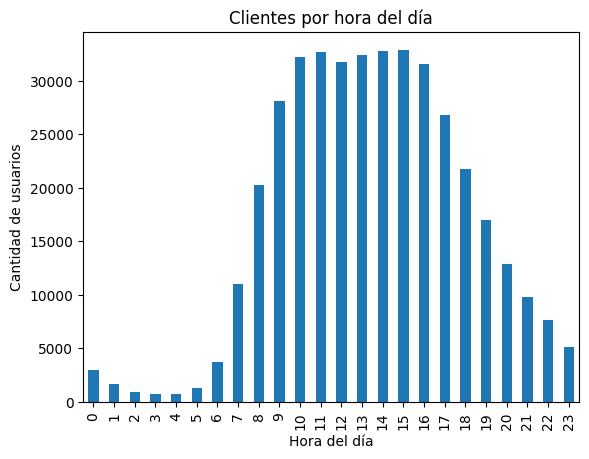

In [37]:
from matplotlib import pyplot as plt

user_per_hour = io.groupby('order_hour_of_day')['user_id'].nunique()
user_per_hour.plot(title = "Clientes por hora del día", kind = 'bar', xlabel = 'Hora del día', ylabel = 'Cantidad de usuarios')
plt.show()


La actividad es variable con respecto a la hora del día, de 10 a 16 horas se registran las horas de mayor actividad registrandose más de 30,000 ingresos por hora, mientras que de las 12 de la media  noche a las 6 de la mañana se registran menos de 5,000 ingresos por hora.

### [A3] ¿Qué día de la semana compran víveres las personas?

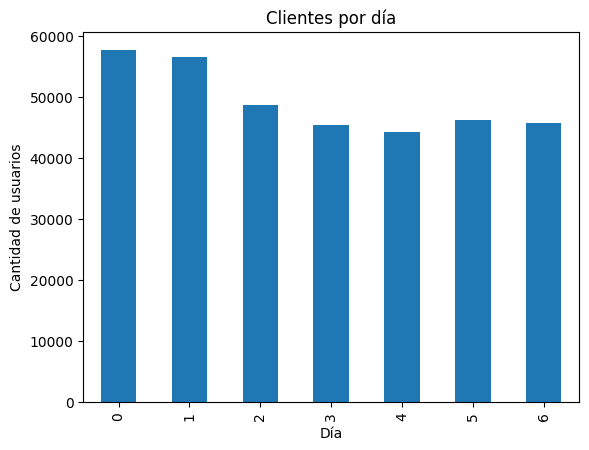

In [38]:

user_per_day = io.groupby('order_dow')['user_id'].nunique()
user_per_day.plot(title = "Clientes por día", kind = 'bar', xlabel = 'Día', ylabel = 'Cantidad de usuarios')
plt.show()


En el gráfico se observa mayor actividad los días domingo y lunes, superando los 50,000 clientes por día y siendo los días en los que se hace la compra de viveres con mayor frecuencia, aunque el resto de días de la semana se mantiene estable la demanda y por encima de los 40,000 pedidos diarios.

### [A4] ¿Cuánto tiempo esperan las personas hasta hacer otro pedido? Comenta sobre los valores mínimos y máximos.

Max  51337 Min  2640


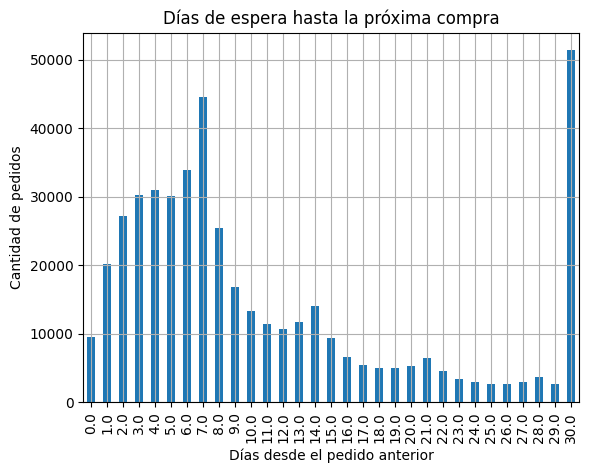

In [39]:
espera = io['days_since_prior_order'].value_counts().sort_index()
espera.plot(title = "Días de espera hasta la próxima compra", grid = True, kind = 'bar', xlabel = 'Días desde el pedido anterior', ylabel = 'Cantidad de pedidos')
print("Max ", espera.max(), "Min ", espera.min())
plt.show()

La mayoría de usuarios realiza su siguiente pedido 30 días despues de haber realizado el anterior (frecuencia de 51,337) y la menor parte de los usuarios espera de 29 a 22 días (frecuencia mínima de 2,640).

# [B] Intermedio (deben completarse todos para aprobar)

1. ¿Existe alguna diferencia entre las distribuciones `'order_hour_of_day'` de los miércoles y los sábados? Traza gráficos de barra de `'order_hour_of_day'` para ambos días en la misma figura y describe las diferencias que observes.
2. Grafica la distribución para el número de órdenes que hacen los clientes (es decir, cuántos clientes hicieron solo 1 pedido, cuántos hicieron 2, cuántos 3, y así sucesivamente...).
3. ¿Cuáles son los 20 principales productos que se piden con más frecuencia (muestra su identificación y nombre)?

### [B1] Diferencia entre miércoles y sábados para  `'order_hour_of_day'`. Traza gráficos de barra para los dos días y describe las diferencias que veas.

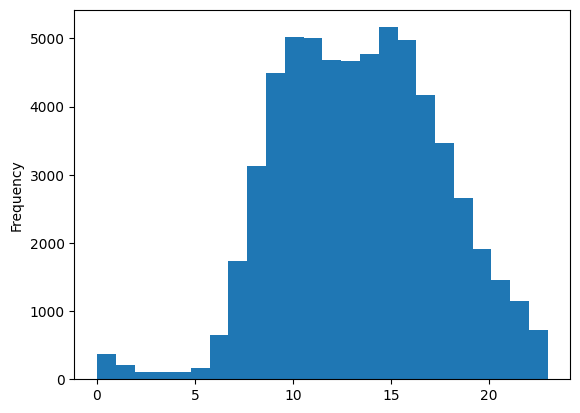

In [40]:
io[io['order_dow'] == 3]['order_hour_of_day'].plot(kind = 'hist', bins = 24)
plt.show()

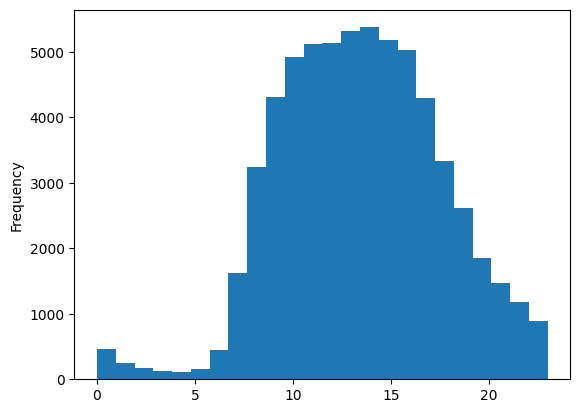

In [41]:
io[io['order_dow'] == 6]['order_hour_of_day'].plot(kind = 'hist', bins = 24)
plt.show()

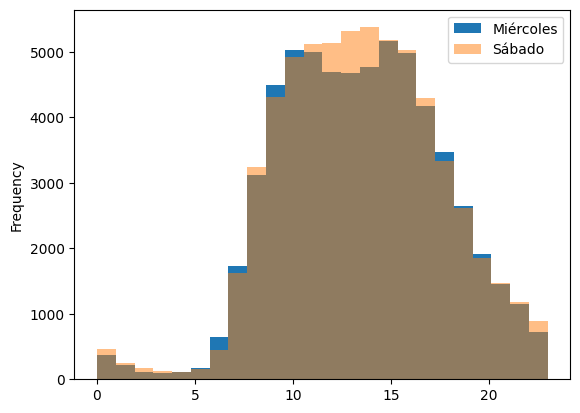

In [42]:
io[io['order_dow'] == 3]['order_hour_of_day'].plot(kind = 'hist', bins = 24)
io[io['order_dow'] == 6]['order_hour_of_day'].plot(kind = 'hist', bins = 24, alpha = 0.5)
plt.legend(['Miércoles', 'Sábado'])
plt.show()

El comportamiento de ambos días es similar a lo largo del día con la expcepción del rango entre las 10 y 15 horas entre las cuales se alcanza la mayor frecuencia de pedidos para el día sábado (frecuencia de más de 5,000 pedidos por hora).

### [B2] ¿Cuál es la distribución para el número de pedidos por cliente?

In [43]:
pxusuario = io.groupby('user_id')['order_id'].nunique()
usuarios_agrupados = pxusuario.value_counts().sort_index()

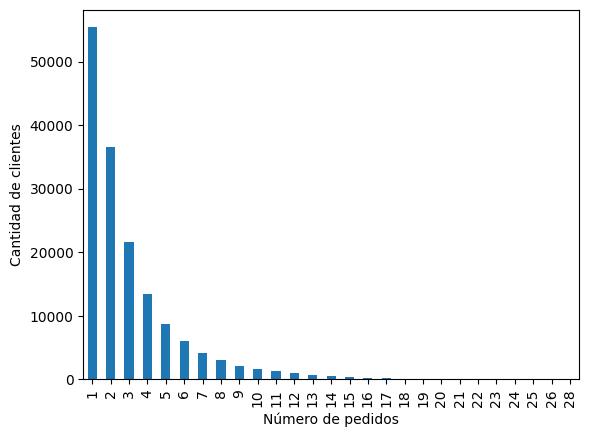

In [44]:
usuarios_agrupados.plot(kind = 'bar', xlabel = 'Número de pedidos', ylabel = 'Cantidad de clientes')
plt.show()

Más de 50,000 usuarios realizaron 1 pedido, más de 35,000 usuarios realizaron 2 pedidos, más de 20,000 usuarios realizaron 3 pedidos, más de 10,000 usuarios realizaron 4 pedidos.

### [B3] ¿Cuáles son los 20 productos más populares (muestra su ID y nombre)?

In [45]:
order_products = op.merge(p[['product_id','product_name']], on='product_id', how='left')

In [46]:
pedidosxproducto = order_products.groupby(['product_id', 'product_name'])['order_id'].count().reset_index()
pedidosxproducto.rename(columns={'order_id': 'cantidad_pedidos'}, inplace=True)
top20productos = pedidosxproducto.sort_values(by= 'cantidad_pedidos', ascending = False)

In [47]:
print(top20productos.head(20))

       product_id              product_name  cantidad_pedidos
22808       24852                    BANANA             66050
12025       13176    BAG OF ORGANIC BANANAS             53297
19370       21137      ORGANIC STRAWBERRIES             37039
20077       21903      ORGANIC BABY SPINACH             33971
43271       47209      ORGANIC HASS AVOCADO             29773
43788       47766           ORGANIC AVOCADO             24689
43663       47626               LARGE LEMON             21495
15364       16797              STRAWBERRIES             20018
24047       26209                     LIMES             19690
25556       27845        ORGANIC WHOLE MILK             19600
25666       27966       ORGANIC RASPBERRIES             19197
21025       22935      ORGANIC YELLOW ONION             15898
22908       24964            ORGANIC GARLIC             15292
41244       45007          ORGANIC ZUCCHINI             14584
35996       39275       ORGANIC BLUEBERRIES             13879
45561   

Se detallan los 20 productos más vendidos resaltando que los primeros dos son Banana y Bag of Organic Bananas.

# [C] Difícil (deben completarse todos para aprobar)

1. ¿Cuántos artículos suelen comprar las personas en un pedido? ¿Cómo es la distribución?
2. ¿Cuáles son los 20 principales artículos que vuelven a pedirse con mayor frecuencia (muestra sus nombres e IDs de los productos)?
3. Para cada producto, ¿cuál es la tasa de repetición del pedido (número de repeticiones de pedido/total de pedidos?
4. Para cada cliente, ¿qué proporción de los productos que pidió ya los había pedido? Calcula la tasa de repetición de pedido para cada usuario en lugar de para cada producto.
5. ¿Cuáles son los 20 principales artículos que la gente pone primero en sus carritos (muestra las IDs de los productos, sus nombres, y el número de veces en que fueron el primer artículo en añadirse al carrito)?

### [C1] ¿Cuántos artículos compran normalmente las personas en un pedido? ¿Cómo es la distribución?

In [48]:
ap = op.groupby('order_id')['product_id'].count()

In [49]:
print(ap.describe())

count    450046.000000
mean         10.098983
std           7.540206
min           1.000000
25%           5.000000
50%           8.000000
75%          14.000000
max         127.000000
Name: product_id, dtype: float64


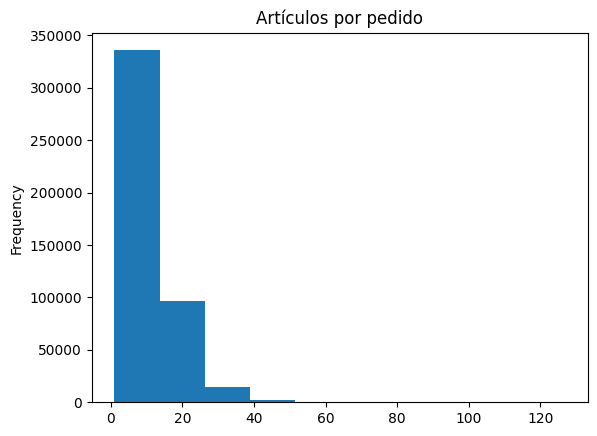

In [50]:
ap.plot(title = "Artículos por pedido", kind = 'hist', xlabel = "Número de artículos", ylabel = "Cantidad de pedidos")
plt.show()

En promedio las personas compran 10 artículos por pedido, como mínimo compran 1 artículo y como máximo han comprado 127 artículos.

### [C2] ¿Cuáles son los 20 principales artículos que vuelven a pedirse con mayor frecuencia (muestra sus nombres e IDs de los productos)?

In [51]:
reorder = order_products[order_products['reordered'] == 1] 

In [52]:
top20reorder = reorder.groupby(['product_id', 'product_name'])['order_id'].count().reset_index()

In [53]:
top20reorder.rename(columns = {'order_id':'veces_reordenado'}, inplace = True)

In [54]:
top20reorder = top20reorder.sort_values(by = 'veces_reordenado', ascending = False)
print(top20reorder.head(20))

       product_id              product_name  veces_reordenado
18104       24852                    BANANA             55763
9528        13176    BAG OF ORGANIC BANANAS             44450
15368       21137      ORGANIC STRAWBERRIES             28639
15936       21903      ORGANIC BABY SPINACH             26233
34407       47209      ORGANIC HASS AVOCADO             23629
34828       47766           ORGANIC AVOCADO             18743
20285       27845        ORGANIC WHOLE MILK             16251
34725       47626               LARGE LEMON             15044
20375       27966       ORGANIC RASPBERRIES             14748
12193       16797              STRAWBERRIES             13945
19088       26209                     LIMES             13327
16700       22935      ORGANIC YELLOW ONION             11145
18186       24964            ORGANIC GARLIC             10411
32792       45007          ORGANIC ZUCCHINI             10076
36219       49683            CUCUMBER KIRBY              9538
20543   

Los productos que se vuelven a pedir con más frecuencia son Banana y Bag of Organic Bananas, concordando con los productos que se piden con más frecuencia.

### [C3] Para cada producto, ¿cuál es la proporción de las veces que se pide y que se vuelve a pedir?

In [55]:
totalpedidos = order_products.groupby(['product_id','product_name'])['order_id'].count()

In [56]:
reordenpedidos = order_products.groupby(['product_id','product_name'])['reordered'].sum()

In [57]:
proporcionreorden = (reordenpedidos / totalpedidos).reset_index()
proporcionreorden.rename(columns = {'reordered':'proporcion'}, inplace = True)
print(proporcionreorden)

       product_id                                       product_name         0
0               1                         CHOCOLATE SANDWICH COOKIES  0.564286
1               2                                   ALL-SEASONS SALT  0.000000
2               3               ROBUST GOLDEN UNSWEETENED OOLONG TEA  0.738095
3               4  SMART ONES CLASSIC FAVORITES MINI RIGATONI WIT...  0.510204
4               7                     PURE COCONUT WATER WITH ORANGE  0.500000
...           ...                                                ...       ...
45568       49690                      HIGH PERFORMANCE ENERGY DRINK  0.800000
45569       49691                      ORIGINAL PANCAKE & WAFFLE MIX  0.430556
45570       49692    ORGANIC INSTANT OATMEAL LIGHT MAPLE BROWN SUGAR  0.416667
45571       49693                             SPRING WATER BODY WASH  0.440000
45572       49694                            BURRITO- STEAK & CHEESE  0.333333

[45573 rows x 3 columns]


Se realizó una tabla con las proporciones de los productos que se vuelven a pedir, con base a esa información podemos deducir que el 56% de los pedidos totales del Chocolate Sandwich Cookies se va a volver a pedir.

### [C4] Para cada cliente, ¿qué proporción de sus productos ya los había pedido?

In [58]:
order_products_m = op.merge(io[['order_id', 'user_id']], on='order_id', how='left')
proporcion_usuario = order_products_m.groupby('user_id')['reordered'].mean().reset_index()
proporcion_usuario.rename(columns={'reordered':'proporcion'}, inplace=True)

In [59]:
print(proporcion_usuario)

        user_id  proporcion
0             2    0.038462
1             4    0.000000
2             5    0.666667
3             6    0.000000
4             7    0.928571
...         ...         ...
149621   206203    0.222222
149622   206206    0.714286
149623   206207    0.891304
149624   206208    0.696000
149625   206209    0.320000

[149626 rows x 2 columns]


Se calculo el porcentaje de recompra por usuario identificando tendencias como: el user_id 7 recompra el 93% de su pedido anterior, mientras que el 4 tiene un porcentaje de 0% ante lo cual se observa que no ha vuelto a comprar.

### [C5] ¿Cuáles son los 20 principales artículos que las personas ponen primero en sus carritos?

In [60]:
primeros_articulos = order_products[order_products['add_to_cart_order'] == 1]

In [61]:
top20primeros = primeros_articulos.groupby(['product_id','product_name'])['order_id'].count().reset_index()
top20primeros.rename(columns = {'order_id':'veces_primer_articulo'}, inplace = True)
top20primeros = top20primeros.sort_values(by = 'veces_primer_articulo', ascending = False)

In [62]:
print(top20primeros.head(20))

       product_id                 product_name  veces_primer_articulo
13414       24852                       BANANA                  15562
7127        13176       BAG OF ORGANIC BANANAS                  11026
15028       27845           ORGANIC WHOLE MILK                   4363
11384       21137         ORGANIC STRAWBERRIES                   3946
25439       47209         ORGANIC HASS AVOCADO                   3390
11786       21903         ORGANIC BABY SPINACH                   3336
25732       47766              ORGANIC AVOCADO                   3044
10622       19660                 SPRING WATER                   2336
9050        16797                 STRAWBERRIES                   2308
15102       27966          ORGANIC RASPBERRIES                   2024
24024       44632   SPARKLING WATER GRAPEFRUIT                   1914
26519       49235          ORGANIC HALF & HALF                   1797
25658       47626                  LARGE LEMON                   1737
115           196   

Se obtienen los principales 20 articulos que las personas agregan a su carrito (como primer articulo agregado), los articulos que más se repiten coincidentemente son Banana y Bag of organic bananas.

### Conclusion general del proyecto:

El análisis de los datos de pedidos de Instacart permitió identificar patrones claros
en la actividad de compra: los usuarios concentran sus pedidos principalmente entre 
las 10:00 y 16:00 horas, con mayor recurrencia los domingos y lunes, manteniendo en 
promedio más de 40,000 órdenes diarias. La frecuencia de recompra muestra que la 
mayoría de clientes repite su pedido aproximadamente cada 30 días, aunque existe una 
amplia variabilidad en el número de órdenes realizadas por usuario. En cuanto al 
consumo, los pedidos suelen incluir en promedio 10 productos, siendo los más vendidos 
y recurrentemente reordenados las bananas. Estos hallazgos reflejan una fuerte 
concentración en ciertos hábitos de compra y productos, lo que constituye información 
clave para la gestión de inventarios, la planificación de campañas promocionales y la 
personalización de la experiencia del cliente.